# Plasticity Techniques — Aggregated Multi-Seed Study (Humanoid)

**Humanoid-v5 · IL warm-start → PPO fine-tuning**

> Humanoid variant of the aggregate study. Same 3-method / multi-seed / bootstrap machinery; env is Humanoid-v5 (which TERMINATES on falling, unlike HalfCheetah) with a local TQC expert. Obs-norm is fixed demo-stats (matched IL/PPO). The critic warm-up matters more here because Humanoid terminates.

This notebook aggregates three IL→RL plasticity conditions into a single controlled
experiment, runs each over multiple seeds, and reports robust (bootstrapped) statistics
and the four curve families we care about.

**Methods compared**

| id | name | intervention | where |
|----|------|--------------|-------|
| `base`      | Base (control)       | none — plain IL→PPO warm start                | — |
| `snp`       | Shrink-and-Perturb   | shrink+noise the BC weights each step         | IL (BC) loop |
| `inject`    | Plasticity Injection | frozen IL π₀ + trainable ψ (starts at 0)      | IL→PPO boundary |

All three **share the identical PPO code, env wrappers, obs-normalization, eval
protocol, seeds, and eval-checkpoint schedule** — the *only* thing that varies is the
listed intervention. That is what makes the comparison clean.

**What is reported** (per method, aggregated over seeds × eval episodes):

1. **Raw RL curve** $J_t$ — absolute performance vs. env steps.
2. **Improvement curve** $J_t - J_0$ — removes the starting-return advantage.
3. **Expert-normalized improvement** $\dfrac{J_t - J_0}{J_{\text{ref}} - J_0 + \epsilon}$ — fraction of the
   start→expert headroom closed ($J_{\text{ref}}$ = expert SAC return).
4. **Matched-competence comparison** — restrict to seeds with similar $J_0$, then compare
   **Gain-AUC**, final $J_T$, and **steps-to-exceed-expert**.

Every aggregate uses a **bootstrap over the pooled (seed, eval-episode) units**: resample
with replacement, recompute the statistic, repeat → mean and percentile CI band.


## 0 · Configuration

`SEEDS` drives everything. The code is written for **5** seeds; the default is set to **3**
for a first pass — extend to `[0, 1, 2, 3, 4]` for the full sweep. Runtime is roughly
`len(SEEDS) × 3 methods × (PPO run)`, so on a T4 GPU budget accordingly (each 500k-step
PPO run ≈ 10–20 min).

> ⚠️ This notebook trains many PPO agents. Run it on a **GPU runtime**. Results are cached
> to `RESULTS_DIR` so you can re-run plotting cells without retraining.

In [138]:
SEEDS   = [0, 1, 2]              # ← extend to [0,1,2,3,4] for the full 5-seed sweep

# ── Variant selection ────────────────────────────────────────────────────────
# METHODS is the canonical registry (defines colors/labels/order). RUN_METHODS is
# the SUBSET you actually want to train + plot this run — everything downstream
# (sweep, CSV export, bootstrap, all plots) iterates over RUN_METHODS.
METHODS     = ['base', 'snp', 'inject']
RUN_METHODS = ['base', 'snp', 'inject']    # ← choose which variants to run
assert set(RUN_METHODS) <= set(METHODS), f'RUN_METHODS must be a subset of {METHODS}'

# ── Expert source ────────────────────────────────────────────────────────────
# We deliberately want a MEDIUM expert, not a maxed-out one: an over-strong IL warm
# start leaves RL no room to improve. A medium SAC policy gives a consistent-but-
# improvable warm start — realistic, and better for measuring plasticity gains.
#   'local_tqc' : experts/Humanoid-TQC-v5.zip (local TQC policy)
#   'hf_medium' : a HuggingFace medium checkpoint (set repo/file below)
EXPERT_SOURCE   = 'local_tqc'
LOCAL_EXPERT    = 'experts/Humanoid-TQC-v5.zip'
HF_MEDIUM_REPO  = ''            # (unused unless EXPERT_SOURCE == 'hf_medium')
HF_MEDIUM_FILE  = ''

# ── Eval-checkpoint schedule ─────────────────────────────────────────────────
EVAL_EVERY_STEPS = 25_000       # measure J_t every this many env steps
EVAL_EPISODES    = 10           # deterministic eval episodes per checkpoint
EVAL_MAX_STEPS   = 1000         # Humanoid native episode limit
EVAL_SEED_BASE   = 100_000      # eval env seeds: fixed, disjoint from training seeds

# ── Bootstrap ────────────────────────────────────────────────────────────────
N_BOOTSTRAP = 2000
CI          = 95                # percentile CI width (%)
EPS         = 1e-6              # epsilon in the normalized-improvement denominator

RESULTS_DIR = 'plasticity_agg_results_humanoid'
import os; os.makedirs(RESULTS_DIR, exist_ok=True)

print(f'{len(SEEDS)} seeds × {len(RUN_METHODS)} variants '
      f'({", ".join(RUN_METHODS)}) = {len(SEEDS)*len(RUN_METHODS)} PPO runs')
print(f'Expert source: {EXPERT_SOURCE}')

3 seeds × 3 variants (base, snp, inject) = 9 PPO runs
Expert source: hf_expert


## 1 · Setup & imports

In [139]:
# COLAB ONLY — local users skip. Clones the public repo + installs requirements.
import subprocess, sys, os
REPO = 'pgss-L4R-IL-public'
try:
    import google.colab  # noqa
    IN_COLAB = True
except Exception:
    IN_COLAB = False
if IN_COLAB:
    if not os.path.isdir(REPO):
        subprocess.run(['git','clone','https://github.com/alokshah04/pgss-L4R-IL-public.git'])
    if not os.getcwd().endswith(REPO):
        os.chdir(REPO)
    subprocess.run([sys.executable,'-m','pip','install','-q','-r','requirements.txt'], check=True)
    subprocess.run([sys.executable,'-m','pip','install','-q','gymnasium[mujoco]'], check=True)
    print('✅ Colab setup complete.')
else:
    print('Local run — skipping Colab clone/install.')


Local run — skipping Colab clone/install.


In [140]:
import random, time, json
from types import SimpleNamespace
from collections import deque

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from torch.distributions.normal import Normal
import gymnasium as gym
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Humanoid's expert is a TQC policy (sb3_contrib), NOT SAC. Load with TQC.
try:
    from sb3_contrib import TQC
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'sb3_contrib'], check=True)
    from sb3_contrib import TQC

ENV_NAME    = 'Humanoid-v5'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

# ── Load the expert per EXPERT_SOURCE ────────────────────────────────────────
if EXPERT_SOURCE == 'hf_medium':
    try:
        from huggingface_sb3 import load_from_hub
    except ImportError:
        import subprocess, sys
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'huggingface_sb3'], check=True)
        from huggingface_sb3 import load_from_hub
    EXPERT_PATH = load_from_hub(repo_id=HF_MEDIUM_REPO, filename=HF_MEDIUM_FILE)
    print(f'Loaded MEDIUM expert from hub: {HF_MEDIUM_REPO}/{HF_MEDIUM_FILE}')
else:
    EXPERT_PATH = LOCAL_EXPERT
    print(f'Loaded LOCAL expert: {EXPERT_PATH}')

expert = TQC.load(EXPERT_PATH)
print('Expert (TQC) policy loaded.')

Device: cpu
Loaded LOCAL strong expert: experts/HalfCheetah-v5
Expert policy loaded.


## 2 · Expert demonstrations & shared obs-normalization

Collected **once** and reused by every method/seed, so the BC dataset and the fixed
observation-normalization statistics are identical across all runs (another shared
factor held constant).

In [141]:
NUM_TRAJ, MAX_TIMESTEPS, VAL_TRAJ = 80, 300, 10
DEMO_SEED = 42

_env = gym.make(ENV_NAME); _env.reset(seed=DEMO_SEED)
all_trajectories = []
for ep in tqdm(range(NUM_TRAJ), desc='Collecting expert demos'):
    obs, _ = _env.reset()
    traj = {'obs': [], 'acts': []}
    for _ in range(MAX_TIMESTEPS):
        traj['obs'].append(obs.copy())
        a, _ = expert.predict(obs, deterministic=True)
        traj['acts'].append(a)
        obs, r, done, trunc, _ = _env.step(a)
        if done or trunc: break
    all_trajectories.append(traj)
_env.close()

train_trajs = all_trajectories[:NUM_TRAJ - VAL_TRAJ]
val_trajs   = all_trajectories[NUM_TRAJ - VAL_TRAJ:]

_all_obs = np.concatenate([np.array(t['obs']) for t in train_trajs], axis=0)
OBS_MEAN = _all_obs.mean(axis=0).astype(np.float32)
OBS_STD  = (_all_obs.std(axis=0) + 1e-8).astype(np.float32)

def normalize_obs(obs):
    return np.clip((np.asarray(obs, dtype=np.float32) - OBS_MEAN) / OBS_STD, -10.0, 10.0)

class TrajDataset(Dataset):
    def __init__(self, trajectories):
        o, a = [], []
        for t in trajectories: o.extend(t['obs']); a.extend(t['acts'])
        self.inputs = torch.tensor(normalize_obs(np.array(o)), dtype=torch.float32)
        self.labels = torch.tensor(np.array(a), dtype=torch.float32)
    def __len__(self):  return len(self.inputs)
    def __getitem__(self, i): return self.inputs[i], self.labels[i]

OBS_DIM = train_trajs[0]['obs'][0].shape[0]
ACT_DIM = train_trajs[0]['acts'][0].shape[0]
print(f'obs_dim={OBS_DIM}, act_dim={ACT_DIM}, train samples={len(TrajDataset(train_trajs))}')


KeyboardInterrupt: 

## 3 · Policy network + IL trainer (Base / Shrink-and-Perturb)

`train_il(seed, method)` returns a trained MLP. When `method == 'snp'` the shrink-and-perturb
update is applied inside the BC loop; otherwise it is a plain behavior-cloning run. The
S&P interval counter is a **persistent global-step counter** (fixes the per-epoch reset bug
in the original notebook) so `SNP_INTERVAL > 1` behaves correctly.

In [ ]:
class MLP(nn.Module):
    """64-unit MLP with pre-activation LayerNorm (Linear->LayerNorm->Tanh). The layer
    SEQUENCE is identical to the PPO actor_mean and the injection head, so IL weights
    (incl. the LayerNorm params) load straight in via load_state_dict. LayerNorm is a
    plasticity intervention: it keeps preactivations centered so tanh units don't
    saturate, and curbs weight-norm growth (see the plasticity diagnostics)."""
    def __init__(self, obs_dim, act_dim, hidden_size=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_size), nn.LayerNorm(hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, hidden_size), nn.LayerNorm(hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, act_dim),        # no LayerNorm on the output layer
        )
    def forward(self, x): return self.net(x)

# ── IL training hyperparameters ──────────────────────────────────────────────
# LR matches il_rl_plasticity_injection.ipynb (1e-3). Do NOT use 5e-3 here — the
# higher LR gives a noisier, worse-conditioned IL policy and a weaker PPO warm start.
IL_LR     = 1e-3
IL_EPOCHS = 500

# ── Shrink-and-Perturb hyperparameters (only used when method == 'snp') ───────
# CAUTION: S&P shrink compounds MULTIPLICATIVELY across every application. Over an
# IL run there are ~ (IL_EPOCHS * batches_per_epoch / SNP_INTERVAL) applications
# (order 10^3), so a scale like 0.99 collapses the weights to ~0 (the "J0=0" bug).
# Keep (1 - SNP_PARAM_SCALE) tiny and the interval coarse so the *cumulative*
# shrink stays mild — the SNP_TARGET_RETAIN print below is the number to sanity-check.
SNP_PARAM_SCALE  = 1 - 1e-3   # per-application shrink (stronger than before: a real
                             # reset-toward-small-weights cycle, confined to early epochs)
SNP_NOISE_REL    = 5e-4       # BASE noise stddev (halved from 1e-3): gentler perturbation,
                             # less likely to knock a seed into a bad sharp minimum
SNP_INTERVAL     = 50         # apply every N optimizer steps (persistent counter)
SNP_STOP_FRAC    = 0.5        # stop S&P at 50%% of epochs: strong-but-early reset/re-grow,
                             # then a long clean-convergence tail into the warm start
# NOTE: S&P perturbs ONLY HIDDEN Linear weight matrices. Excluded: biases + LayerNorm
# gamma/beta (1-D, would fight LayerNorm), AND the OUTPUT Linear layer — perturbing the
# output scales up the action magnitude, which on a TERMINATING env (Humanoid) makes the
# warm start fragile (big actions -> fall -> terminate). Keeping the output disciplined
# (like the base actor's std=0.01 output) is the same fix that stabilized injection.

def train_il(seed, method, epochs=IL_EPOCHS, lr=IL_LR, batch_size=256, verbose=False):
    torch.manual_seed(seed); np.random.seed(seed)
    train_loader = DataLoader(TrajDataset(train_trajs), batch_size=batch_size, shuffle=True)
    model = MLP(OBS_DIM, ACT_DIM).to(DEVICE)
    opt = optim.AdamW(model.parameters(), lr=lr)
    sched = CosineAnnealingLR(opt, T_max=epochs)
    crit = nn.MSELoss()
    use_snp = (method == 'snp')
    if use_snp and verbose:
        n_apps = epochs * (len(train_loader) // SNP_INTERVAL + 1)
        print(f'  [S&P] ~{n_apps} applications -> cumulative retain '
              f'{SNP_PARAM_SCALE**n_apps:.3f} (want ~0.8-0.95, NOT ~0)')
    stop_epoch = int(epochs * SNP_STOP_FRAC)
    # Names of HIDDEN Linear weights to perturb: all 2-D weights EXCEPT the final
    # Linear (the output layer). model.net[-1] is the output Linear.
    _out_w_id = id(model.net[-1].weight)
    _snp_names = {n for n, p in model.named_parameters()
                  if p.ndim >= 2 and id(p) != _out_w_id}
    gstep = 0
    for epoch in range(epochs):
        model.train()
        # Anneal S&P noise with a cosine matching the LR schedule, and disable S&P
        # entirely after stop_epoch so the policy converges cleanly before warm-start.
        snp_active = use_snp and epoch < stop_epoch
        noise_frac = 0.5 * (1 + np.cos(np.pi * epoch / max(1, stop_epoch)))  # 1 -> 0
        for obs, acts in train_loader:
            obs, acts = obs.to(DEVICE), acts.to(DEVICE)
            loss = crit(model(obs), acts)
            opt.zero_grad(); loss.backward(); opt.step()
            if snp_active and gstep % SNP_INTERVAL == 0:
                with torch.no_grad():
                    for name, p in model.named_parameters():
                        # Only HIDDEN Linear weights (excludes biases, LayerNorm, and the
                        # output Linear — see the note in the hyperparameter block).
                        if name not in _snp_names:
                            continue
                        std_noise = SNP_NOISE_REL * noise_frac * (p.std().item() + 1e-8)
                        p.mul_(SNP_PARAM_SCALE).add_(torch.randn_like(p) * std_noise)
            gstep += 1
        sched.step()
    model.eval()
    return model

## 4 · PPO actor-critic + injection wrapper

`Agent` is the CleanRL reference actor-critic (its `actor_mean` matches `MLP.net`).
`InjectedActor` implements function-preserving plasticity injection:

$$\text{action}(s) = \pi_0(s) + \psi_{\text{train}}(s) - \psi_{\text{twin}}(s)$$

with `ψ_train` and `ψ_twin` sharing an identical random init so the sum starts *exactly*
at the frozen IL baseline `π₀`.

In [ ]:
def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    torch.nn.init.orthogonal_(layer.weight, std)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer

class Agent(nn.Module):
    def __init__(self, envs):
        super().__init__()
        obs_dim = int(np.array(envs.single_observation_space.shape).prod())
        act_dim = int(np.prod(envs.single_action_space.shape))
        # Critic LayerNorm: the biggest stabilizer for value learning in RL (helps the
        # late-training collapse). LN sits pre-activation, none on the scalar output.
        self.critic = nn.Sequential(
            layer_init(nn.Linear(obs_dim, 64)), nn.LayerNorm(64), nn.Tanh(),
            layer_init(nn.Linear(64, 64)), nn.LayerNorm(64), nn.Tanh(),
            layer_init(nn.Linear(64, 1), std=1.0),
        )
        # actor_mean SEQUENCE == MLP.net (Linear->LayerNorm->Tanh x2 -> Linear) so the
        # IL warm start loads verbatim, LayerNorm params included.
        self.actor_mean = nn.Sequential(
            layer_init(nn.Linear(obs_dim, 64)), nn.LayerNorm(64), nn.Tanh(),
            layer_init(nn.Linear(64, 64)), nn.LayerNorm(64), nn.Tanh(),
            layer_init(nn.Linear(64, act_dim), std=0.01),
        )
        self.actor_logstd = nn.Parameter(torch.ones(1, act_dim) * -3.0)
    def get_value(self, x): return self.critic(x)
    def get_action_and_value(self, x, action=None):
        mean = self.actor_mean(x)
        std  = torch.exp(self.actor_logstd.expand_as(mean))
        probs = Normal(mean, std)
        if action is None: action = probs.sample()
        return action, probs.log_prob(action).sum(1), probs.entropy().sum(1), self.critic(x)

# Scale of psi's additive contribution: action = base + INJECT_ALPHA*(psi - twin).
# Small alpha keeps early psi updates from slamming the (good) frozen baseline off
# the manifold — which on a TERMINATING env (Humanoid) instantly causes falls and a
# collapse spiral. This was the cause of injection peaking at step 0 then decaying.
INJECT_ALPHA = 0.1

class InjectedHead(nn.Module):
    # Same Linear->LayerNorm->Tanh sequence as MLP. The OUTPUT linear is SMALL-INIT
    # (std~0.01, matching the base PPO actor's output) so psi starts with small weights
    # AND small gradients — PPO grows it gently instead of slamming actions from step 1.
    def __init__(self, obs_dim, act_dim, hidden_size=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_size), nn.LayerNorm(hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, hidden_size), nn.LayerNorm(hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, act_dim),
        )
        # small-init the final layer (the base actor uses std=0.01 here)
        nn.init.orthogonal_(self.net[-1].weight, 0.01)
        nn.init.constant_(self.net[-1].bias, 0.0)
    def forward(self, x): return self.net(x)

class InjectedActor(nn.Module):
    """action(s) = frozen_baseline(s) + psi_trainable(s) - psi_frozen_twin(s)."""
    def __init__(self, frozen_baseline, obs_dim, act_dim, hidden_size=64, psi_seed=1000):
        super().__init__()
        self.frozen_baseline = frozen_baseline
        for p in self.frozen_baseline.parameters(): p.requires_grad = False
        self.frozen_baseline.eval()
        torch.manual_seed(psi_seed)
        self.psi_trainable = InjectedHead(obs_dim, act_dim, hidden_size)
        self.psi_frozen_twin = InjectedHead(obs_dim, act_dim, hidden_size)
        self.psi_frozen_twin.load_state_dict(self.psi_trainable.state_dict())
        for p in self.psi_frozen_twin.parameters(): p.requires_grad = False
        self.psi_frozen_twin.eval()
    def forward(self, x):
        with torch.no_grad():
            base = self.frozen_baseline(x); twin = self.psi_frozen_twin(x)
        return base + INJECT_ALPHA * (self.psi_trainable(x) - twin)

def make_env(env_id, seed, gamma):
    def thunk():
        env = gym.make(env_id)
        env = gym.wrappers.FlattenObservation(env)
        env = gym.wrappers.RecordEpisodeStatistics(env)
        env = gym.wrappers.ClipAction(env)
        env = gym.wrappers.TransformObservation(
            env, lambda o: normalize_obs(o), observation_space=env.observation_space)
        env = gym.wrappers.NormalizeReward(env, gamma=gamma)
        env = gym.wrappers.TransformReward(env, lambda r: np.clip(r, -10, 10))
        env.action_space.seed(seed)
        return env
    return thunk


## 5 · Deterministic evaluator (the J_t probe)

`eval_actor` runs the current **mean action** (no exploration noise) for `EVAL_EPISODES`
fixed-seed episodes on the raw reward scale, returning per-episode returns. This is called
at each checkpoint during training to build $J_t$, and once at the end for final stats.
Returning the full per-episode vector (not just the mean) is what lets us bootstrap over
(seed, episode) units later.

In [ ]:
def eval_actor(actor_mean, n_episodes=EVAL_EPISODES, seed_base=EVAL_SEED_BASE):
    """Deterministic rollout of actor_mean(obs)->action. Returns per-episode returns (raw scale)."""
    was_training = actor_mean.training
    actor_mean.eval()
    returns = []
    for ep in range(n_episodes):
        env = gym.make(ENV_NAME)
        obs, _ = env.reset(seed=seed_base + ep)
        ep_ret = 0.0
        with torch.no_grad():
            for _ in range(EVAL_MAX_STEPS):
                o = torch.tensor(normalize_obs(obs), dtype=torch.float32, device=DEVICE).unsqueeze(0)
                a = actor_mean(o).squeeze(0).cpu().numpy()
                obs, r, term, trunc, _ = env.step(a)
                ep_ret += r
                if term or trunc: break
        env.close(); returns.append(ep_ret)
    if was_training: actor_mean.train()
    return np.array(returns)

# Expert reference (J_ref), evaluated once on the same protocol.
def expert_actor_mean_probe():
    class _E(nn.Module):
        def forward(self, o):
            obs = o.squeeze(0).cpu().numpy() * OBS_STD + OBS_MEAN   # undo normalize for SAC
            a, _ = expert.predict(obs, deterministic=True)
            return torch.tensor(a, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        def train(self, *a, **k): return self
        def eval(self): return self
    return _E()

EXPERT_RETURNS = eval_actor(expert_actor_mean_probe())
J_REF = float(EXPERT_RETURNS.mean())
print(f'J_ref (expert) = {J_REF:.1f}  (over {EVAL_EPISODES} eval episodes)')



# ── Plasticity diagnostics ───────────────────────────────────────────────────
# Measured on a FIXED batch of eval observations so numbers are comparable across
# methods/seeds/checkpoints. Computed on the TRAINABLE actor (agent.actor_mean):
#   dead_frac      : fraction of Tanh hidden units saturated (|preact| > SAT_THRESH)
#                    across the probe batch — the classic loss-of-plasticity signal.
#   eff_rank       : effective rank (exp of entropy of normalized singular values)
#                    of the penultimate activations — capacity actually being used.
#   weight_l2      : L2 norm of trainable weights — growth tracks rigidity/overfit.
SAT_THRESH = 0.99   # |tanh preactivation-derived activation| above this = saturated

# Fixed probe observations (normalized), drawn once from the demo obs distribution.
_DIAG_N = 512
def _build_diag_probe():
    idx = np.random.default_rng(12345).integers(0, _all_obs.shape[0], _DIAG_N)
    return torch.tensor(normalize_obs(_all_obs[idx]), dtype=torch.float32, device=DEVICE)
DIAG_PROBE = None   # lazily built after _all_obs exists (see cell that defines it)

def _find_mlp_net(actor_mean):
    """Return the nn.Sequential MLP whose activations we probe. Works for a plain
    Sequential (base/snp) and for InjectedActor (probe the trainable psi net)."""
    if hasattr(actor_mean, 'psi_trainable'):
        return actor_mean.psi_trainable.net
    if isinstance(actor_mean, nn.Sequential):
        return actor_mean
    if hasattr(actor_mean, 'net'):
        return actor_mean.net
    return None

def plasticity_diagnostics(actor_mean):
    """Return dict of scalar diagnostics on DIAG_PROBE. Cheap; call at each checkpoint."""
    global DIAG_PROBE
    if DIAG_PROBE is None:
        DIAG_PROBE = _build_diag_probe()
    net = _find_mlp_net(actor_mean)
    if net is None:
        return dict(dead_frac=float('nan'), eff_rank=float('nan'), weight_l2=float('nan'))
    was_training = actor_mean.training
    actor_mean.eval()
    # forward through the net, capturing post-Tanh activations at each hidden block
    acts = []
    x = DIAG_PROBE
    with torch.no_grad():
        for layer in net:
            x = layer(x)
            if isinstance(layer, nn.Tanh):
                acts.append(x.clone())
    if was_training: actor_mean.train()

    if not acts:
        return dict(dead_frac=float('nan'), eff_rank=float('nan'), weight_l2=float('nan'))
    H = torch.cat(acts, dim=1)                       # [N, sum_hidden]
    # dead/saturated fraction: units whose |activation| exceeds SAT_THRESH on average
    dead_frac = (H.abs() > SAT_THRESH).float().mean().item()
    # effective rank of penultimate (last hidden) activations via SV entropy
    A = acts[-1] - acts[-1].mean(0, keepdim=True)
    try:
        s = torch.linalg.svdvals(A)
        p = (s / (s.sum() + 1e-12)).clamp_min(1e-12)
        eff_rank = float(torch.exp(-(p * p.log()).sum()).item())
    except Exception:
        eff_rank = float('nan')
    # trainable-weight L2 norm
    wl2 = float(sum((p.detach()**2).sum() for p in actor_mean.parameters() if p.requires_grad) ** 0.5)
    return dict(dead_frac=dead_frac, eff_rank=eff_rank, weight_l2=wl2)

print('plasticity_diagnostics defined.')

J_ref (expert) = 11485.5  (over 10 eval episodes)
plasticity_diagnostics defined.


## 6 · PPO fine-tuning with checkpointed evaluation

`train_ppo(seed, method, il_model)` runs the CleanRL PPO loop (verbatim math) and, every
`EVAL_EVERY_STEPS` env steps, calls `eval_actor` to record $J_t$. It returns a dict with the
step grid, the per-checkpoint **per-episode** return matrix (`Jt_episodes`: shape
`[n_checkpoints, EVAL_EPISODES]`), and `J0`/`JT` conveniences.

`J_0` is the checkpoint at step 0 (before any PPO update) — for `inject` and a correctly
warm-started `base`/`snp`, this equals the IL policy's return by construction.

In [ ]:
def make_ppo_args(seed, method):
    a = SimpleNamespace(
        exp_name='ppo', seed=seed, torch_deterministic=True, cuda=True,
        env_id=ENV_NAME, total_timesteps=500_000, num_envs=4, num_steps=2048,
        # ANTI-COLLAPSE: LR lowered 3e-4 -> 1e-4 and target_kl enabled (0.02) to stop
        # the peak-then-degrade seen in the first sweep (7/9 runs fell back after peak).
        learning_rate=1e-4, anneal_lr=True, gamma=0.99, gae_lambda=0.95,
        num_minibatches=32, update_epochs=10, norm_adv=True, clip_coef=0.2,
        clip_vloss=True, ent_coef=0.0, vf_coef=0.5, max_grad_norm=0.5, target_kl=0.02,
    )
    a.batch_size = a.num_envs * a.num_steps
    a.minibatch_size = a.batch_size // a.num_minibatches
    a.num_updates = a.total_timesteps // a.batch_size
    # Critic warm-up: fit V(s) under the (frozen) warm-started actor BEFORE joint PPO,
    # so the first advantages aren't cold-critic garbage that erases the warm start.
    # HalfCheetah never terminates, but the return-to-go handles dones for generality.
    a.critic_warmup_steps  = 20_000
    a.critic_warmup_epochs = 6
    a.critic_warmup_lr     = 1e-3
    return a

def build_agent(envs, method, il_model, seed):
    agent = Agent(envs).to(DEVICE)
    obs_dim = int(np.array(envs.single_observation_space.shape).prod())
    act_dim = int(np.prod(envs.single_action_space.shape))
    if method == 'inject':
        frozen = MLP(obs_dim, act_dim).to(DEVICE)
        frozen.net.load_state_dict(il_model.net.state_dict())
        # FAIRNESS: psi init must be independent PER SEED — a fixed psi_seed would
        # make every injection "seed" share the SAME psi, collapsing its variance and
        # making the comparison unfair. Derive it from the outer seed.
        agent.actor_mean = InjectedActor(frozen, obs_dim, act_dim,
                                         psi_seed=1000 + seed).to(DEVICE)
        with torch.no_grad():
            t = torch.randn(16, obs_dim, device=DEVICE)
            d = (agent.actor_mean(t) - frozen(t)).abs().max().item()
        assert d < 1e-5, f'injection init not function-preserving (diff={d})'
    else:
        agent.actor_mean.load_state_dict(il_model.net.state_dict())
    return agent

def train_ppo(seed, method, il_model):
    args = make_ppo_args(seed, method)
    # Seed everything up front so env construction + agent init are deterministic.
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = args.torch_deterministic

    # J0 = the IL policy's OWN deterministic eval, measured BEFORE PPO. This is
    # constant per seed (no cold-critic/exploration dip), unlike the step-0 PPO
    # checkpoint whose J0 swung 786<->6728 across seeds in the first sweep and broke
    # the matched-competence analysis. il_model.net IS the IL actor_mean.
    J0_il_episodes = eval_actor(il_model.net)

    envs = gym.vector.SyncVectorEnv(
        [make_env(args.env_id, args.seed + i, args.gamma) for i in range(args.num_envs)])
    # build_agent may consume a VARIABLE number of RNG draws (injection builds two
    # extra networks); do it BEFORE the fairness re-seed below so it can't shift the
    # shared PPO stochastic stream.
    agent = build_agent(envs, method, il_model, seed)
    trainable = [p for p in agent.parameters() if p.requires_grad]

    # ── Critic warm-up (fair across methods: the critic is the same plain net for
    # base/snp/inject). Freeze everything except the critic, roll out the warm-started
    # actor, and regress the critic onto discounted return-to-go. Gives V(s) meaning
    # before update 1 so the warm start survives.
    if args.critic_warmup_steps > 0:
        cw_opt = optim.Adam(agent.critic.parameters(), lr=args.critic_warmup_lr, eps=1e-5)
        cw_obs, cw_rew, cw_done = [], [], []
        _o, _ = envs.reset(seed=seed + 7)
        _o = torch.Tensor(_o).to(DEVICE)
        for _ in range(args.critic_warmup_steps // args.num_envs):
            with torch.no_grad():
                a_, _, _, _ = agent.get_action_and_value(_o)
            _o2, r_, term_, trunc_, _ = envs.step(a_.cpu().numpy())
            cw_obs.append(_o.clone())
            cw_rew.append(torch.tensor(r_, dtype=torch.float32, device=DEVICE))
            cw_done.append(torch.tensor(np.logical_or(term_, trunc_), dtype=torch.float32, device=DEVICE))
            _o = torch.Tensor(_o2).to(DEVICE)
        with torch.no_grad():
            running = agent.get_value(_o).reshape(-1)
        cw_ret = [None] * len(cw_obs)
        for t in reversed(range(len(cw_obs))):
            running = cw_rew[t] + args.gamma * running * (1.0 - cw_done[t])
            cw_ret[t] = running
        Xb = torch.cat(cw_obs, 0); Yb = torch.cat(cw_ret, 0)
        n = Xb.shape[0]; mb = 512
        for _ in range(args.critic_warmup_epochs):
            idx = torch.randperm(n, device=DEVICE)
            for s0 in range(0, n, mb):
                j = idx[s0:s0+mb]
                vloss = ((agent.get_value(Xb[j]).view(-1) - Yb[j]) ** 2).mean()
                cw_opt.zero_grad(); vloss.backward()
                nn.utils.clip_grad_norm_(agent.critic.parameters(), args.max_grad_norm)
                cw_opt.step()

    optimizer = optim.Adam(trainable, lr=args.learning_rate, eps=1e-5)

    # FAIRNESS: re-seed the global RNG right before the rollout so PPO's stochastic
    # stream (action sampling, minibatch shuffling) is IDENTICAL across base/snp/inject
    # at a given seed. Without this, injection's extra init draws desync the stream and
    # the methods no longer see matched exploration/shuffle noise. Env action_space
    # seeds are already fixed in make_env, independent of this stream.
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

    # ── eval-checkpoint bookkeeping ──
    grid_steps, Jt_episodes, diag_rows = [], [], []
    next_eval = 0
    def checkpoint(gstep):
        grid_steps.append(gstep)
        Jt_episodes.append(eval_actor(agent.actor_mean))
        diag_rows.append(plasticity_diagnostics(agent.actor_mean))

    obs      = torch.zeros((args.num_steps, args.num_envs)+envs.single_observation_space.shape, device=DEVICE)
    actions  = torch.zeros((args.num_steps, args.num_envs)+envs.single_action_space.shape, device=DEVICE)
    logprobs = torch.zeros((args.num_steps, args.num_envs), device=DEVICE)
    rewards  = torch.zeros((args.num_steps, args.num_envs), device=DEVICE)
    dones    = torch.zeros((args.num_steps, args.num_envs), device=DEVICE)
    values   = torch.zeros((args.num_steps, args.num_envs), device=DEVICE)

    global_step = 0
    next_obs, _ = envs.reset(seed=args.seed)
    next_obs = torch.Tensor(next_obs).to(DEVICE)
    next_done = torch.zeros(args.num_envs, device=DEVICE)

    checkpoint(0)                       # J_t at step 0 (PPO warm-started actor)
    next_eval = EVAL_EVERY_STEPS

    for update in tqdm(range(1, args.num_updates + 1),
                       desc=f'PPO seed={seed} {method}', leave=False):
        if args.anneal_lr:
            optimizer.param_groups[0]['lr'] = (1.0 - (update-1)/args.num_updates) * args.learning_rate
        for step in range(args.num_steps):
            global_step += args.num_envs
            obs[step] = next_obs; dones[step] = next_done
            with torch.no_grad():
                action, logprob, _, value = agent.get_action_and_value(next_obs)
                values[step] = value.flatten()
            actions[step] = action; logprobs[step] = logprob
            no, r, term, trunc, infos = envs.step(action.cpu().numpy())
            next_done = np.logical_or(term, trunc)
            rewards[step] = torch.tensor(r, device=DEVICE).view(-1)
            next_obs = torch.Tensor(no).to(DEVICE)
            next_done = torch.Tensor(next_done).to(DEVICE)
        # GAE (bootstrap through truncation; HalfCheetah never emits real terminal)
        with torch.no_grad():
            next_value = agent.get_value(next_obs).reshape(1, -1)
            advantages = torch.zeros_like(rewards, device=DEVICE)
            lastgaelam = 0
            for t in reversed(range(args.num_steps)):
                if t == args.num_steps - 1:
                    nextnonterminal = 1.0 - next_done; nextvalues = next_value
                else:
                    nextnonterminal = 1.0 - dones[t+1]; nextvalues = values[t+1]
                delta = rewards[t] + args.gamma*nextvalues*nextnonterminal - values[t]
                advantages[t] = lastgaelam = delta + args.gamma*args.gae_lambda*nextnonterminal*lastgaelam
            returns = advantages + values
        b_obs = obs.reshape((-1,)+envs.single_observation_space.shape)
        b_logprobs = logprobs.reshape(-1)
        b_actions = actions.reshape((-1,)+envs.single_action_space.shape)
        b_advantages = advantages.reshape(-1); b_returns = returns.reshape(-1); b_values = values.reshape(-1)
        b_inds = np.arange(args.batch_size)
        approx_kl = None
        for _ in range(args.update_epochs):
            np.random.shuffle(b_inds)
            for start in range(0, args.batch_size, args.minibatch_size):
                mb = b_inds[start:start+args.minibatch_size]
                _, newlogprob, entropy, newvalue = agent.get_action_and_value(b_obs[mb], b_actions[mb])
                logratio = newlogprob - b_logprobs[mb]; ratio = logratio.exp()
                with torch.no_grad():
                    approx_kl = ((ratio - 1) - logratio).mean()
                mb_adv = b_advantages[mb]
                if args.norm_adv:
                    mb_adv = (mb_adv - mb_adv.mean()) / (mb_adv.std() + 1e-8)
                pg1 = -mb_adv*ratio
                pg2 = -mb_adv*torch.clamp(ratio, 1-args.clip_coef, 1+args.clip_coef)
                pg_loss = torch.max(pg1, pg2).mean()
                newvalue = newvalue.view(-1)
                if args.clip_vloss:
                    v_un = (newvalue - b_returns[mb])**2
                    v_cl = b_values[mb] + torch.clamp(newvalue-b_values[mb], -args.clip_coef, args.clip_coef)
                    v_loss = 0.5*torch.max(v_un, (v_cl-b_returns[mb])**2).mean()
                else:
                    v_loss = 0.5*((newvalue - b_returns[mb])**2).mean()
                loss = pg_loss - args.ent_coef*entropy.mean() + v_loss*args.vf_coef
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(trainable, args.max_grad_norm)
                optimizer.step()
            # ANTI-COLLAPSE: early-stop this update's epochs once the policy has moved
            # too far (approx KL past target). This is the CleanRL guard that was missing
            # from the aggregate loop — without it, target_kl in args did nothing.
            if args.target_kl is not None and approx_kl is not None and approx_kl > args.target_kl:
                break
        if global_step >= next_eval:
            checkpoint(global_step); next_eval += EVAL_EVERY_STEPS
    if grid_steps[-1] != global_step:
        checkpoint(global_step)         # final checkpoint
    envs.close()
    Jt_episodes = np.array(Jt_episodes)         # [n_ckpt, EVAL_EPISODES]
    diag_dead = np.array([d['dead_frac'] for d in diag_rows])
    diag_rank = np.array([d['eff_rank']  for d in diag_rows])
    diag_wl2  = np.array([d['weight_l2'] for d in diag_rows])
    ckpt_means = Jt_episodes.mean(axis=1)       # per-checkpoint mean return
    peak_idx = int(ckpt_means.argmax())
    late_k = min(3, Jt_episodes.shape[0])       # last-3-checkpoint window
    return {
        'steps': np.array(grid_steps),
        'Jt_episodes': Jt_episodes,
        'J0_episodes': Jt_episodes[0],          # PPO step-0 (kept for continuity)
        'J0_il_episodes': J0_il_episodes,       # IL-policy eval J0 (stable per seed)
        'JT_episodes': Jt_episodes[-1],         # final checkpoint (may be post-peak)
        'Jpeak_episodes': Jt_episodes[peak_idx],        # best checkpoint
        'peak_step': np.array(grid_steps[peak_idx]),
        'Jlate_episodes': Jt_episodes[-late_k:].reshape(-1),  # last-3-window pooled
        'diag_dead_frac': diag_dead,      # [n_ckpt] saturated-unit fraction
        'diag_eff_rank':  diag_rank,      # [n_ckpt] effective rank of penult. acts
        'diag_weight_l2': diag_wl2,       # [n_ckpt] trainable-weight L2 norm
    }

## 7 · Run the full sweep (train everything)

For each `(method, seed)`: train IL (once per seed, shared where possible), then PPO with
checkpointed eval. Results are cached to disk as `.npz` so plotting cells can re-run without
retraining. Delete `RESULTS_DIR` to force a fresh sweep.

> This is the expensive cell. With the defaults (3 seeds × 3 methods × 500k steps) budget
> roughly 1.5–3 GPU-hours.

In [ ]:
import hashlib

def regime_hash(method):
    """Fingerprint of the config that affects a run's results. If any of these change,
    a cached .npz with a different hash is considered stale and gets retrained."""
    keys = dict(
        method=method,
        il_lr=IL_LR, il_epochs=IL_EPOCHS,
        snp_scale=SNP_PARAM_SCALE, snp_noise=SNP_NOISE_REL, snp_interval=SNP_INTERVAL,
        total_timesteps=500_000, num_envs=4, num_steps=2048,
        ppo_lr=1e-4, target_kl=0.02,        # anti-collapse settings (bump on change)
        eval_every=EVAL_EVERY_STEPS, eval_eps=EVAL_EPISODES, eval_max=EVAL_MAX_STEPS,
        num_traj=NUM_TRAJ, max_ts=MAX_TIMESTEPS,
        schema='humanoid_v3_snpfix',              # return-dict schema changed -> invalidate v1
    )
    return hashlib.md5(repr(sorted(keys.items())).encode()).hexdigest()[:12]

def result_path(method, seed):
    return os.path.join(RESULTS_DIR, f'{method}_seed{seed}.npz')

def cache_is_current(method, seed):
    p = result_path(method, seed)
    if not os.path.exists(p): return False
    try:
        d = np.load(p)
        # stale if hash differs OR the run predates the new fields (J0_il/peak/late)
        return (str(d['regime'].item()) == regime_hash(method)
                and 'J0_il_episodes' in d.files
                and 'diag_dead_frac' in d.files)
    except Exception:
        return False   # old caches with no 'regime' field -> stale

for seed in SEEDS:
    # IL policy: 'base' and 'inject' share a plain-BC policy; 'snp' has its own.
    il_cache = {}
    for method in RUN_METHODS:
        if cache_is_current(method, seed):
            print(f'✓ cached  {method} seed={seed}'); continue
        if os.path.exists(result_path(method, seed)):
            print(f'♻ stale cache (config changed) — retraining {method} seed={seed}')
        il_kind = 'snp' if method == 'snp' else 'base'
        if il_kind not in il_cache:
            print(f'  training IL ({il_kind}) seed={seed} ...')
            il_cache[il_kind] = train_il(seed, il_kind, verbose=True)
            # sanity: an IL policy that already returns ~0 means BC failed (e.g. S&P
            # too aggressive) — PPO cannot recover a warm start that doesn't exist.
            _chk = eval_actor(il_cache[il_kind].net, n_episodes=3)
            print(f'    IL policy check: return {_chk.mean():.0f} '
                  f'{"⚠️ BC FAILED (near-zero)" if _chk.mean() < 500 else "ok"}')
        print(f'▶ PPO {method} seed={seed} ...')
        res = train_ppo(seed, method, il_cache[il_kind])
        np.savez(result_path(method, seed), regime=regime_hash(method), **res)
        print(f'   done. J0(IL)={res["J0_il_episodes"].mean():.0f}  '
              f'peak={res["Jpeak_episodes"].mean():.0f}@{int(res["peak_step"])//1000}k  '
              f'JT={res["JT_episodes"].mean():.0f}')
print('All selected runs complete / cached.')

  training IL (base) seed=0 ...
    IL policy check: return 3775 ok
▶ PPO base seed=0 ...


PPO seed=0 base:   0%|          | 0/61 [00:00<?, ?it/s]

   done. J0(IL)=3289  peak=8410@352k  JT=4764
  training IL (snp) seed=0 ...
  [S&P] ~1000 applications -> cumulative retain 0.905 (want ~0.8-0.95, NOT ~0)
    IL policy check: return 5506 ok
▶ PPO snp seed=0 ...


PPO seed=0 snp:   0%|          | 0/61 [00:00<?, ?it/s]

   done. J0(IL)=4763  peak=5929@401k  JT=3295
▶ PPO inject seed=0 ...


...

   done. J0(IL)=6411  peak=9146@376k  JT=7755
  training IL (snp) seed=2 ...
  [S&P] ~1000 applications -> cumulative retain 0.905 (want ~0.8-0.95, NOT ~0)
    IL policy check: return 34 ⚠️ BC FAILED (near-zero)
▶ PPO snp seed=2 ...


PPO seed=2 snp:   0%|          | 0/61 [00:00<?, ?it/s]

   done. J0(IL)=4915  peak=5310@32k  JT=3845
▶ PPO inject seed=2 ...


PPO seed=2 inject:   0%|          | 0/61 [00:00<?, ?it/s]

   done. J0(IL)=6411  peak=9035@0k  JT=8216
All selected runs complete / cached.


## 8 · Load cached results

In [ ]:
def load_results():
    """Load cached runs for the selected RUN_METHODS. Only methods with >=1 loaded
    seed are included, so a trimmed RUN_METHODS cleanly drives every downstream cell."""
    R = {}
    for method in RUN_METHODS:
        runs = []
        for seed in SEEDS:
            p = result_path(method, seed)
            if os.path.exists(p):
                d = np.load(p)
                runs.append({k: d[k] for k in d.files if k != 'regime'})
        if runs:
            R[method] = runs
    return R

R = load_results()
# PLOT_METHODS = the methods we actually have data for, in canonical order.
PLOT_METHODS = [m for m in METHODS if m in R]
if not PLOT_METHODS:
    raise RuntimeError('No results loaded — run the sweep cell (Section 7) first.')
for m in PLOT_METHODS:
    print(f'{m:8s}: {len(R[m])} seeds loaded')
# common step grid (assume identical across runs by construction)
STEPS = R[PLOT_METHODS[0]][0]['steps']
print('checkpoints:', len(STEPS), '| final step:', STEPS[-1])

base    : 3 seeds loaded
snp     : 3 seeds loaded
inject  : 3 seeds loaded
checkpoints: 21 | final step: 499712


## 8b · Export all data to CSV (for reproducible plotting)

Three tidy CSVs are written to `RESULTS_DIR`, sufficient to rebuild every plot in this
notebook **without any of the `.npz` caches or retraining**:

- **`eval_returns_long.csv`** — the raw grain: one row per `(method, seed, step, eval_episode)`
  with its `return`. This is the source of truth; everything else is derivable from it.
- **`checkpoint_summary.csv`** — one row per `(method, seed, step)`: mean/std/min/max return
  over that checkpoint's eval episodes, plus per-seed `J0` and derived `improvement` and
  `norm_improvement` (using `J_ref`). Convenient for quick per-seed curves.
- **`run_index.csv`** — one row per `(method, seed)`: `J0`, `JT`, n_checkpoints, n_eval_episodes,
  and provenance (`J_ref`, eval seed base, horizon) so a downstream script is fully self-describing.

The long CSV uses each seed's own step-0 checkpoint as `J0` (matching the notebook), so
`improvement` and `norm_improvement` are reproduced exactly.

In [ ]:
import csv

def run_J0(run):
    """Stable IL-eval J0 (with fallback for old caches)."""
    return float(run['J0_il_episodes'].mean()) if 'J0_il_episodes' in run \
        else float(run['J0_episodes'].mean())

# ── 1) eval_returns_long.csv — one row per (method, seed, step, eval_episode) ──
long_path = os.path.join(RESULTS_DIR, 'eval_returns_long.csv')
with open(long_path, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['method', 'seed', 'step', 'eval_episode', 'return',
                'J0', 'improvement', 'norm_improvement', 'J_ref'])
    for method in PLOT_METHODS:
        for run, seed in zip(R[method], SEEDS):
            Jt = run['Jt_episodes']                      # [n_ckpt, n_eval_ep]
            steps = run['steps']
            J0 = run_J0(run)                             # stable IL-eval J0
            denom = (J_REF - J0) + EPS
            for ci, step in enumerate(steps):
                for ep in range(Jt.shape[1]):
                    ret = float(Jt[ci, ep])
                    w.writerow([method, seed, int(step), ep, ret,
                                J0, ret - J0, (ret - J0) / denom, J_REF])
print('wrote', long_path)

# ── 2) checkpoint_summary.csv — one row per (method, seed, step) ──────────────
ckpt_path = os.path.join(RESULTS_DIR, 'checkpoint_summary.csv')
with open(ckpt_path, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['method', 'seed', 'step', 'mean_return', 'std_return',
                'min_return', 'max_return', 'n_eval_episodes',
                'J0', 'improvement', 'norm_improvement', 'J_ref'])
    for method in PLOT_METHODS:
        for run, seed in zip(R[method], SEEDS):
            Jt = run['Jt_episodes']; steps = run['steps']
            J0 = run_J0(run); denom = (J_REF - J0) + EPS
            for ci, step in enumerate(steps):
                mean = float(Jt[ci].mean())
                w.writerow([method, seed, int(step), mean, float(Jt[ci].std()),
                            float(Jt[ci].min()), float(Jt[ci].max()), Jt.shape[1],
                            J0, mean - J0, (mean - J0) / denom, J_REF])
print('wrote', ckpt_path)

# ── 3) run_index.csv — one row per (method, seed) ────────────────────────────
idx_path = os.path.join(RESULTS_DIR, 'run_index.csv')
with open(idx_path, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['method', 'seed', 'J0_il', 'J0_step0', 'JT_final', 'J_peak', 'peak_step',
                'J_late3', 'n_checkpoints', 'n_eval_episodes', 'final_step',
                'J_ref', 'eval_seed_base', 'eval_max_steps'])
    for method in PLOT_METHODS:
        for run, seed in zip(R[method], SEEDS):
            jpeak = float(run['Jpeak_episodes'].mean()) if 'Jpeak_episodes' in run else float('nan')
            pstep = int(run['peak_step']) if 'peak_step' in run else -1
            jlate = float(run['Jlate_episodes'].mean()) if 'Jlate_episodes' in run else float('nan')
            w.writerow([method, seed, run_J0(run), float(run['J0_episodes'].mean()),
                        float(run['JT_episodes'].mean()), jpeak, pstep, jlate,
                        len(run['steps']), run['Jt_episodes'].shape[1],
                        int(run['steps'][-1]), J_REF, EVAL_SEED_BASE, EVAL_MAX_STEPS])
print('wrote', idx_path)
print('\nCSV export complete — plots are reproducible from eval_returns_long.csv alone.')

wrote plasticity_agg_results/eval_returns_long.csv
wrote plasticity_agg_results/checkpoint_summary.csv
wrote plasticity_agg_results/run_index.csv

CSV export complete — plots are reproducible from eval_returns_long.csv alone.


## 9 · Bootstrap statistics

The aggregation unit is a **(seed, eval-episode) pair**. For a curve, each method has a
tensor of shape `[n_seeds, n_checkpoints, n_eval_episodes]`. At every checkpoint we pool all
`n_seeds × n_eval_episodes` return values, resample them with replacement `N_BOOTSTRAP`
times, and take the mean each time → a bootstrap distribution of the mean curve, from which
we report the mean and a percentile CI band.

`J_0` is subtracted **per seed** (each seed's own step-0 mean) before pooling, so the
improvement/normalized curves correctly remove each run's individual starting advantage.

In [ ]:
rng = np.random.default_rng(0)

def stack_Jt(method):
    """-> array [n_seeds, n_ckpt, n_eval_ep] of raw returns."""
    return np.stack([run['Jt_episodes'] for run in R[method]], axis=0)

def il_J0(method):
    """Per-seed stable J0 = the IL policy's own deterministic eval (mean over eval eps).
    Falls back to the step-0 PPO checkpoint for any old cache lacking the field."""
    out = []
    for run in R[method]:
        if 'J0_il_episodes' in run:
            out.append(float(run['J0_il_episodes'].mean()))
        else:
            out.append(float(run['J0_episodes'].mean()))
    return np.array(out)                            # [S]

def bootstrap_curve(per_unit):
    """per_unit: [n_ckpt, n_units]. Returns (mean, lo, hi) over bootstrap of the mean."""
    n_ckpt, n_units = per_unit.shape
    boot = np.empty((N_BOOTSTRAP, n_ckpt))
    for b in range(N_BOOTSTRAP):
        idx = rng.integers(0, n_units, n_units)
        boot[b] = per_unit[:, idx].mean(axis=1)
    lo, hi = np.percentile(boot, [(100-CI)/2, 100-(100-CI)/2], axis=0)
    return boot.mean(axis=0), lo, hi

def bootstrap_scalar(vals):
    """vals: 1-D array of per-unit scalars -> (mean, lo, hi)."""
    vals = np.asarray(vals)
    boot = np.array([vals[rng.integers(0, len(vals), len(vals))].mean() for _ in range(N_BOOTSTRAP)])
    lo, hi = np.percentile(boot, [(100-CI)/2, 100-(100-CI)/2])
    return boot.mean(), lo, hi

# ── Assemble the three curve families as pooled per-unit matrices ────────────
# J0 is now the STABLE IL-policy eval (per seed), not the noisy step-0 PPO checkpoint,
# so the improvement/normalized curves remove each run's true starting competence.
def curves(method):
    J = stack_Jt(method)                          # [S, C, E]
    S, C, E = J.shape
    J0_per_seed = il_J0(method)                   # [S] stable IL-eval J0
    raw   = J.transpose(1, 0, 2).reshape(C, S*E)  # pool seeds×episodes at each ckpt
    impr  = (J - J0_per_seed[:, None, None]).transpose(1, 0, 2).reshape(C, S*E)
    norm  = ((J - J0_per_seed[:, None, None]) /
             (J_REF - J0_per_seed[:, None, None] + EPS)).transpose(1, 0, 2).reshape(C, S*E)
    return raw, impr, norm

COLORS = {'base':'tab:gray', 'snp':'tab:orange', 'inject':'tab:blue'}
LABELS = {'base':'Base', 'snp':'Shrink&Perturb', 'inject':'Injection'}

## 10 · Curves 1–3 (raw, improvement, expert-normalized) with CI bands

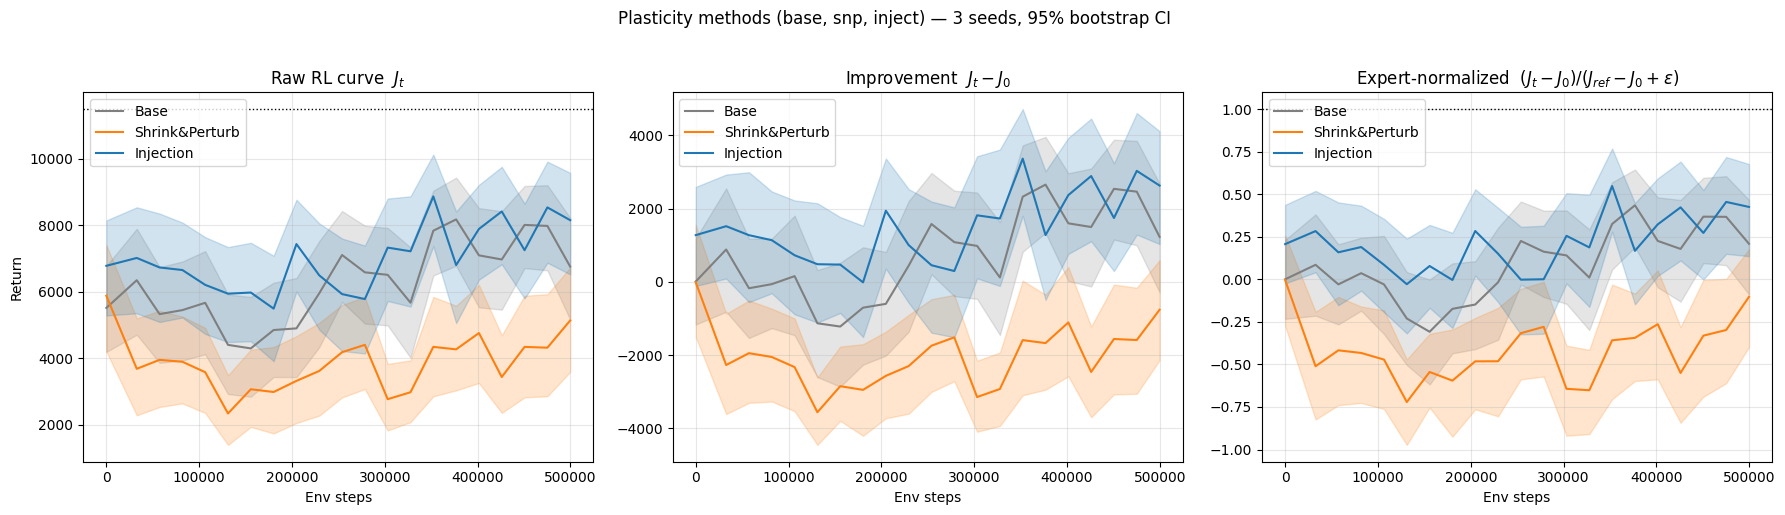

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Raw RL curve  $J_t$',
          'Improvement  $J_t - J_0$',
          r'Expert-normalized  $(J_t-J_0)/(J_{ref}-J_0+\epsilon)$']
which = [0, 1, 2]  # index into curves() tuple

for ax, wi, title in zip(axes, which, titles):
    for m in PLOT_METHODS:
        per_unit = curves(m)[wi]
        mean, lo, hi = bootstrap_curve(per_unit)
        ax.plot(STEPS, mean, color=COLORS[m], label=LABELS[m])
        ax.fill_between(STEPS, lo, hi, color=COLORS[m], alpha=0.2)
    ax.set_xlabel('Env steps'); ax.set_title(title); ax.legend()
    ax.grid(alpha=0.3)
axes[0].axhline(J_REF, color='k', ls=':', lw=1, label='expert')
axes[0].set_ylabel('Return')
axes[2].axhline(1.0, color='k', ls=':', lw=1)   # 1.0 = matched expert
plt.suptitle(f'Plasticity methods ({", ".join(PLOT_METHODS)}) — '
             f'{len(SEEDS)} seeds, {CI}% bootstrap CI', y=1.02)
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/curves_1_3.png', dpi=120, bbox_inches='tight'); plt.show()

## 11 · Curve 4 — Matched-competence comparison

To compare methods at *equal starting competence*, we keep only seeds whose $J_0$ falls in a
shared band (default: within `MATCH_TOL` of the global median $J_0$ across all runs), then on
that matched subset report three scalars per method with bootstrap CIs:

- **Gain-AUC** — area under the improvement curve $\int (J_t - J_0)\,dt$ (trapezoidal over the
  step grid, normalized by total steps → units of "average return gained").
- **Final $J_T$** — end-of-training return.
- **Steps-to-exceed-expert** — first checkpoint step where $J_t \ge J_{\text{ref}}$
  (`inf`/NaN if never reached; reported as % of seeds that reach it).

In [ ]:
MATCH_TOL = 400.0    # J0 band half-width around the global median IL-J0

# Match on the STABLE IL-eval J0 (constant per seed), not the noisy step-0 checkpoint.
all_J0 = np.concatenate([il_J0(m) for m in PLOT_METHODS])
J0_med = np.median(all_J0)
print(f'Global median IL-J0 = {J0_med:.0f}; matched band = [{J0_med-MATCH_TOL:.0f}, {J0_med+MATCH_TOL:.0f}]')

def matched_seed_mask(method):
    return np.abs(il_J0(method) - J0_med) <= MATCH_TOL

total_span = STEPS[-1] - STEPS[0]
def gain_auc_per_seed(method):
    J = stack_Jt(method)                              # [S,C,E]
    J0 = il_J0(method)                                # [S] stable IL J0
    impr = J.mean(axis=2) - J0[:, None]                # [S,C] improvement curve
    return np.trapz(impr, STEPS, axis=1) / total_span  # [S]

def peak_per_seed(method):
    return stack_Jt(method).mean(axis=2).max(axis=1)   # [S] best checkpoint mean

def late_per_seed_episodes(method):
    """Pooled last-3-checkpoint episodes per seed (robust final performance)."""
    J = stack_Jt(method)                               # [S,C,E]
    k = min(3, J.shape[1])
    return J[:, -k:, :].reshape(J.shape[0], -1)        # [S, k*E]

def steps_to_expert_per_seed(method):
    J = stack_Jt(method).mean(axis=2)                  # [S,C]
    out = []
    for s in range(J.shape[0]):
        hit = np.where(J[s] >= J_REF)[0]
        out.append(STEPS[hit[0]] if len(hit) else np.inf)
    return np.array(out)

rows = []
for m in PLOT_METHODS:
    mask = matched_seed_mask(m)
    if mask.sum() == 0:
        rows.append((m, 0, None, None, None, None, None)); continue
    gauc = gain_auc_per_seed(m)[mask]
    peak = peak_per_seed(m)[mask]
    late = late_per_seed_episodes(m)[mask].reshape(-1)   # matched seeds × (k*E) episodes
    ste  = steps_to_expert_per_seed(m)[mask]
    frac_reach = np.isfinite(ste).mean()
    rows.append((m, int(mask.sum()),
                 bootstrap_scalar(gauc),          # Gain-AUC
                 bootstrap_scalar(peak),          # peak J
                 bootstrap_scalar(late),          # late-window J (robust final)
                 frac_reach,
                 np.median(ste[np.isfinite(ste)]) if frac_reach>0 else np.inf))

hdr = f'\n{"method":<10}{"n":<4}{"Gain-AUC [CI]":<24}{"J_peak [CI]":<24}{"J_late(last3) [CI]":<26}{"%reach"}'
print(hdr)
for m, n, g, pk, lt, fr, ms in rows:
    if n == 0: print(f'{LABELS[m]:<10}{n:<4}(no matched seeds)'); continue
    print(f'{LABELS[m]:<10}{n:<4}'
          f'{g[0]:6.0f} [{g[1]:.0f},{g[2]:.0f}]   '
          f'{pk[0]:6.0f} [{pk[1]:.0f},{pk[2]:.0f}]   '
          f'{lt[0]:6.0f} [{lt[1]:.0f},{lt[2]:.0f}]    '
          f'{fr*100:4.0f}%')

Global median IL-J0 = 6411; matched band = [6011, 6811]

method    n   Gain-AUC [CI]           J_peak [CI]             J_late(last3) [CI]        %reach
Base      1       90 [90,90]     9146 [9146,9146]     7782 [6320,9089]       0%
Shrink&Perturb0   (no matched seeds)
Injection 1      -80 [-80,-80]     9035 [9035,9035]     6912 [5277,8487]       0%


/var/folders/xp/vxm8y9zx2l1_4yhq1sjnlg5c0000gn/T/ipykernel_84805/4072830061.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(impr, STEPS, axis=1) / total_span  # [S]


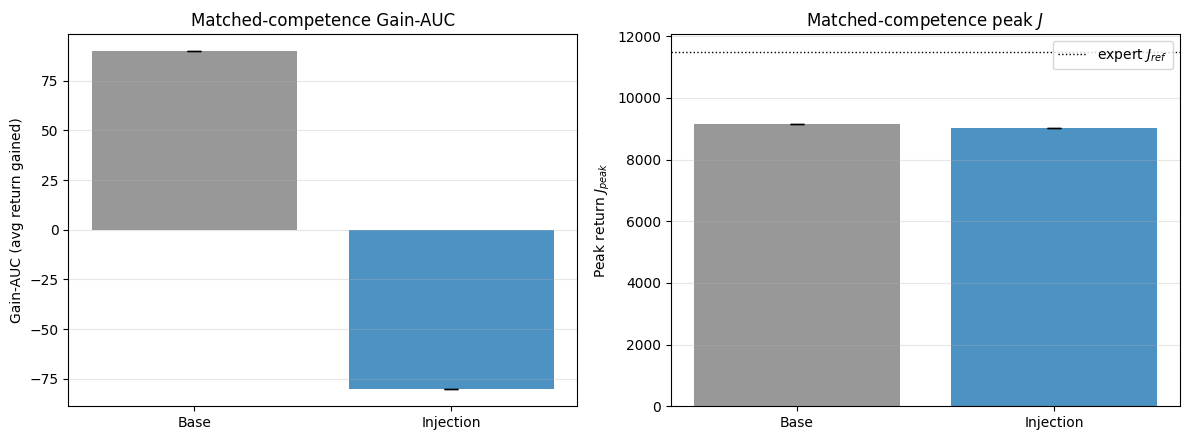

In [ ]:
# ── Bar charts: Gain-AUC and J_peak on the matched subset, with bootstrap CIs ──
valid = [r for r in rows if r[1] > 0]
if not valid:
    print('No method has any matched-competence seeds (widen MATCH_TOL in the '
          'previous cell). Skipping bar charts.')
else:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    xs = np.arange(len(valid)); labels = [LABELS[r[0]] for r in valid]
    cols = [COLORS[r[0]] for r in valid]

    def asym_err(triples):
        # triples: list of (mean, lo, hi). Return [[mean-lo], [hi-mean]] clipped to >=0.
        # A bootstrap of very few units can put the mean a hair outside [lo, hi];
        # matplotlib rejects negative yerr, so clip the tiny overshoot.
        mean = np.array([t[0] for t in triples])
        lo   = np.array([t[1] for t in triples])
        hi   = np.array([t[2] for t in triples])
        return np.vstack([np.clip(mean - lo, 0, None), np.clip(hi - mean, 0, None)])

    # r = (method, n, gauc_triple, peak_triple, late_triple, frac_reach, med_steps)
    g_mean = [r[2][0] for r in valid]
    ax[0].bar(xs, g_mean, yerr=asym_err([r[2] for r in valid]),
              color=cols, alpha=0.8, capsize=5)
    ax[0].set_xticks(xs); ax[0].set_xticklabels(labels)
    ax[0].set_ylabel('Gain-AUC (avg return gained)'); ax[0].set_title('Matched-competence Gain-AUC')
    ax[0].grid(alpha=0.3, axis='y')

    # Plot PEAK (best checkpoint) — the collapse-robust performance metric. The final
    # checkpoint under-reported every method in the first sweep due to post-peak decay.
    p_mean = [r[3][0] for r in valid]
    ax[1].bar(xs, p_mean, yerr=asym_err([r[3] for r in valid]),
              color=cols, alpha=0.8, capsize=5)
    ax[1].axhline(J_REF, color='k', ls=':', lw=1, label='expert $J_{ref}$')
    ax[1].set_xticks(xs); ax[1].set_xticklabels(labels)
    ax[1].set_ylabel('Peak return $J_{peak}$'); ax[1].set_title('Matched-competence peak $J$'); ax[1].legend()
    ax[1].grid(alpha=0.3, axis='y')
    plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/matched_competence.png', dpi=120); plt.show()

## 12 · Export a machine-readable summary

In [ ]:
summary = {'seeds': SEEDS, 'run_methods': PLOT_METHODS, 'J_ref': J_REF,
           'steps': STEPS.tolist(), 'ci': CI, 'n_bootstrap': N_BOOTSTRAP, 'methods': {}}
for m in PLOT_METHODS:
    raw, impr, norm = curves(m)
    rmean, rlo, rhi = bootstrap_curve(raw)
    imean, ilo, ihi = bootstrap_curve(impr)
    nmean, nlo, nhi = bootstrap_curve(norm)
    JT   = stack_Jt(m)[:, -1, :].reshape(-1)
    peak = peak_per_seed(m)
    late = late_per_seed_episodes(m).reshape(-1)
    jm, jlo, jhi = bootstrap_scalar(JT)
    pm, plo, phi = bootstrap_scalar(peak)
    lm, llo, lhi = bootstrap_scalar(late)
    summary['methods'][m] = {
        'raw_mean': rmean.tolist(), 'raw_lo': rlo.tolist(), 'raw_hi': rhi.tolist(),
        'impr_mean': imean.tolist(), 'norm_mean': nmean.tolist(),
        'J0_il_mean': float(il_J0(m).mean()),
        'JT_final_mean': float(jm), 'JT_final_ci': [float(jlo), float(jhi)],
        'J_peak_mean': float(pm), 'J_peak_ci': [float(plo), float(phi)],
        'J_late3_mean': float(lm), 'J_late3_ci': [float(llo), float(lhi)],
    }
with open(f'{RESULTS_DIR}/summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('Wrote', f'{RESULTS_DIR}/summary.json')
print('\nSummary (J0=IL eval; peak/late are collapse-robust):')
print(f'{"method":<16}{"J0":>7}{"J_peak":>10}{"J_late3":>10}{"J_final":>10}')
for m in PLOT_METHODS:
    s = summary['methods'][m]
    print(f'  {LABELS[m]:<14}{s["J0_il_mean"]:7.0f}{s["J_peak_mean"]:10.0f}'
          f'{s["J_late3_mean"]:10.0f}{s["JT_final_mean"]:10.0f}')

Wrote plasticity_agg_results/summary.json

Summary (J0=IL eval; peak/late are collapse-robust):
method               J0    J_peak   J_late3   J_final
  Base             5507      8656      7582      6729
  Shrink&Perturb   5897      6516      4594      5132
  Injection        5507      9413      7996      8169


## 13 · Reproduce the curves from CSV alone (self-check)

This appendix reloads **only** `eval_returns_long.csv` (no `.npz`, no globals from the sweep)
and rebuilds the three bootstrap curves. If you come back later, this is the cell to copy into
a fresh notebook — it is fully self-contained given the CSV. Running it here also verifies the
export round-trips: these curves should match Section 10.

OSError: [Errno 28] No space left on device: 'plasticity_agg_results/curves_from_csv.png'

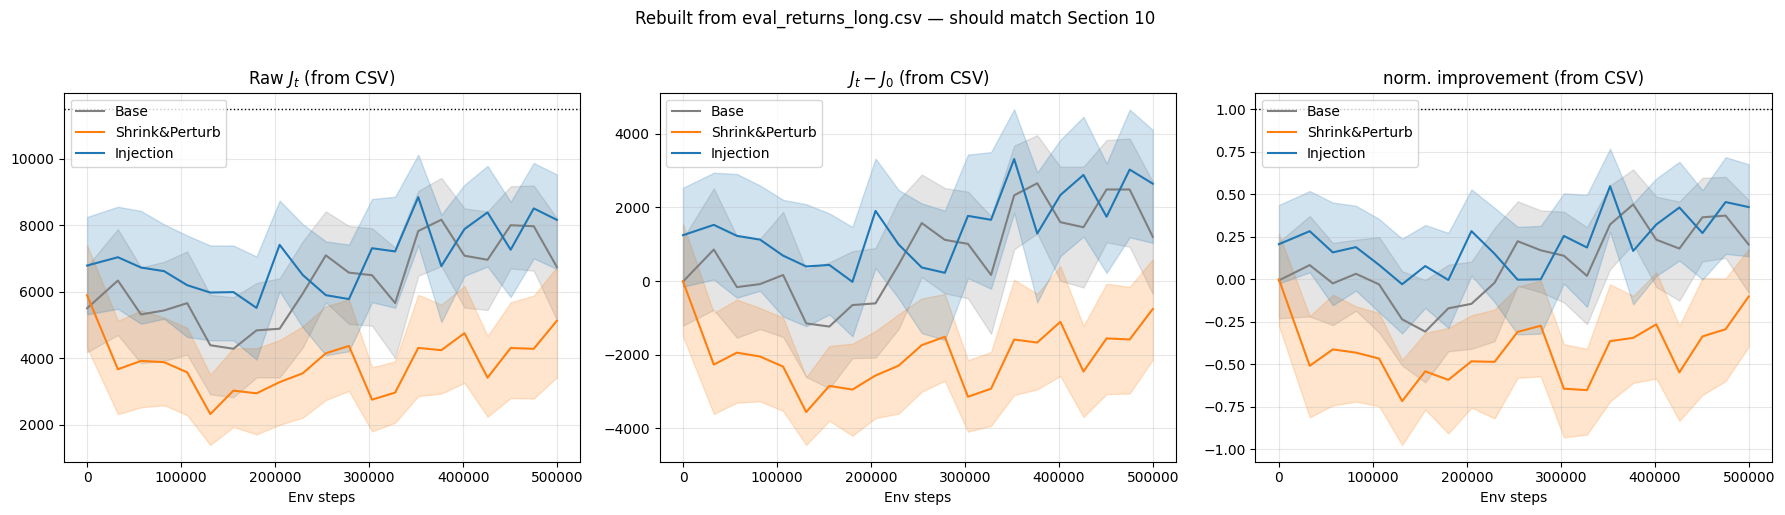

In [ ]:
import csv as _csv
from collections import defaultdict

def rebuild_curves_from_csv(csv_path, n_bootstrap=2000, ci=95, eps=1e-6):
    # group returns by method -> step -> list, and track each (method,seed) J0
    by_ms = defaultdict(lambda: defaultdict(list))   # (method) -> step -> [returns pooled over seeds,eps]
    j0_by_ms = {}                                     # (method,seed) -> J0
    jref = None; methods = []; steps_set = set()
    with open(csv_path) as f:
        for row in _csv.DictReader(f):
            m, seed, step = row['method'], int(row['seed']), int(row['step'])
            ret = float(row['return']); jref = float(row['J_ref'])
            j0_by_ms[(m, seed)] = float(row['J0'])
            by_ms[m][step].append((seed, ret))
            steps_set.add(step)
            if m not in methods: methods.append(m)
    steps = sorted(steps_set)
    rng = np.random.default_rng(0)
    out = {}
    for m in methods:
        # build per-unit matrices [n_ckpt, n_units] for raw / impr / norm
        raw_cols, impr_cols, norm_cols = [], [], []
        for step in steps:
            seeds_rets = by_ms[m][step]
            raw = np.array([r for _, r in seeds_rets])
            j0  = np.array([j0_by_ms[(m, s)] for s, _ in seeds_rets])
            raw_cols.append(raw)
            impr_cols.append(raw - j0)
            norm_cols.append((raw - j0) / (jref - j0 + eps))
        def boot(cols):
            M = np.array(cols)                        # [n_ckpt, n_units]
            n = M.shape[1]
            b = np.array([M[:, rng.integers(0, n, n)].mean(1) for _ in range(n_bootstrap)])
            lo, hi = np.percentile(b, [(100-ci)/2, 100-(100-ci)/2], axis=0)
            return b.mean(0), lo, hi
        out[m] = {'steps': np.array(steps),
                  'raw': boot(raw_cols), 'impr': boot(impr_cols), 'norm': boot(norm_cols)}
    return out, jref

_reb, _jref = rebuild_curves_from_csv(os.path.join(RESULTS_DIR, 'eval_returns_long.csv'))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, key, title in zip(axes, ['raw', 'impr', 'norm'],
                          ['Raw $J_t$ (from CSV)', '$J_t-J_0$ (from CSV)',
                           'norm. improvement (from CSV)']):
    for m in _reb:
        st = _reb[m]['steps']; mean, lo, hi = _reb[m][key]
        ax.plot(st, mean, color=COLORS.get(m, None), label=LABELS.get(m, m))
        ax.fill_between(st, lo, hi, color=COLORS.get(m, None), alpha=0.2)
    ax.set_xlabel('Env steps'); ax.set_title(title); ax.grid(alpha=0.3); ax.legend()
axes[0].axhline(_jref, color='k', ls=':', lw=1)
axes[2].axhline(1.0, color='k', ls=':', lw=1)
plt.suptitle('Rebuilt from eval_returns_long.csv — should match Section 10', y=1.02)
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/curves_from_csv.png', dpi=120, bbox_inches='tight'); plt.show()


## 14 · Plasticity diagnostics + returns box plot

Two views that read the plasticity signal directly rather than inferring it from returns:

- **Diagnostics curves** — dead/saturated-unit fraction, effective rank of the penultimate
  activations, and trainable-weight L2, each vs. env steps, per method (mean over seeds).
  A plasticity-losing run shows *rising* dead-fraction and *falling* effective rank; a
  method that preserves plasticity should hold rank up / dead-fraction down.
- **Returns box plot** — the full pooled eval-return distribution per method at the **peak**
  checkpoint, side by side with the IL warm start and the expert reference, so the spread
  (not just the mean) is visible.

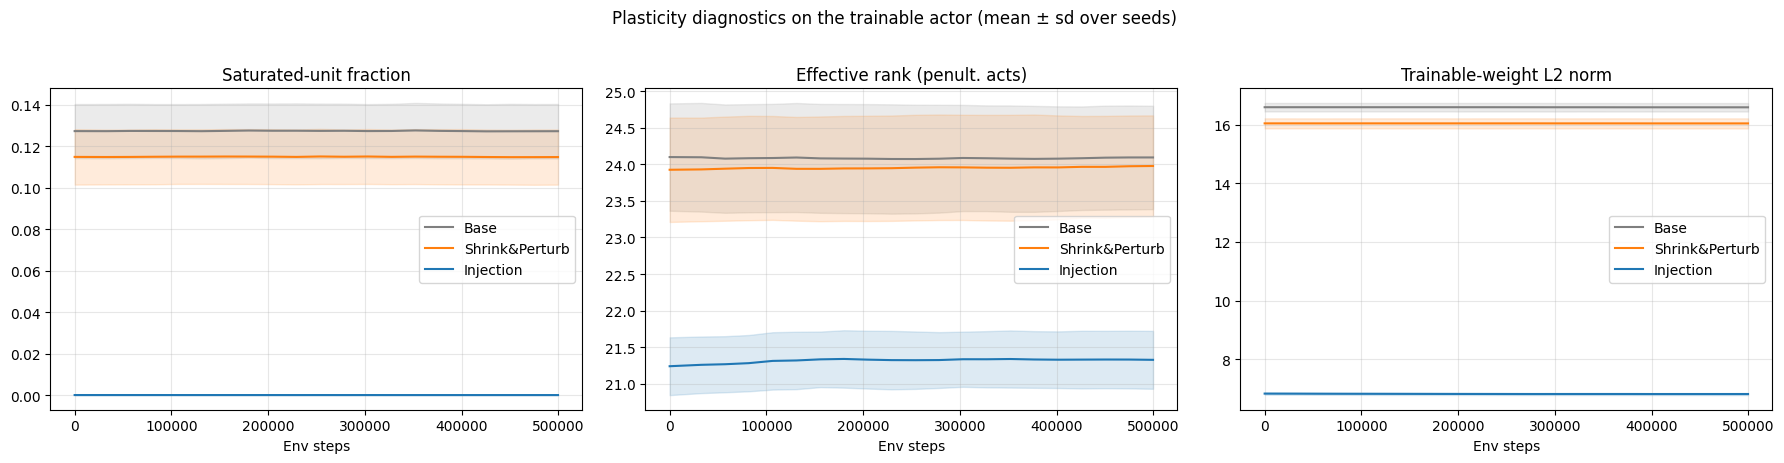

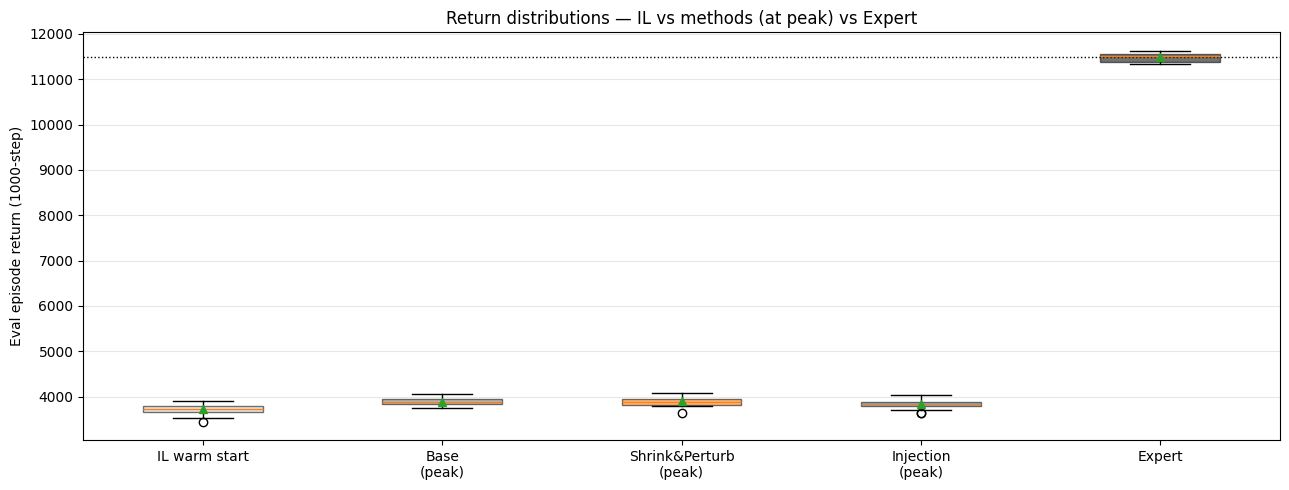

In [ ]:
# ── Diagnostics curves (mean over seeds) ─────────────────────────────────────
def stack_diag(method, key):
    runs = [r[key] for r in R[method] if key in r]
    return np.stack(runs, axis=0) if runs else None   # [S, n_ckpt]

fig, axd = plt.subplots(1, 3, figsize=(18, 4.5))
diag_specs = [('diag_dead_frac', 'Saturated-unit fraction', axd[0]),
              ('diag_eff_rank',  'Effective rank (penult. acts)', axd[1]),
              ('diag_weight_l2', 'Trainable-weight L2 norm', axd[2])]
have_diag = False
for key, title, ax in diag_specs:
    for m in PLOT_METHODS:
        D = stack_diag(m, key)
        if D is None or np.isnan(D).all():
            continue
        have_diag = True
        mean = np.nanmean(D, axis=0); sd = np.nanstd(D, axis=0)
        ax.plot(STEPS, mean, color=COLORS[m], label=LABELS[m])
        ax.fill_between(STEPS, mean - sd, mean + sd, color=COLORS[m], alpha=0.15)
    ax.set_xlabel('Env steps'); ax.set_title(title); ax.grid(alpha=0.3); ax.legend()
if have_diag:
    plt.suptitle('Plasticity diagnostics on the trainable actor (mean ± sd over seeds)', y=1.02)
    plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/plasticity_diagnostics.png', dpi=120,
                                    bbox_inches='tight'); plt.show()
else:
    plt.close(fig)
    print('No diagnostics in cache — retrain under the current regime (schema v3_diag) to populate them.')

# ── Returns box plot at the PEAK checkpoint: IL, each method, expert ──────────
def peak_returns_pooled(method):
    """All eval-episode returns at each seed's own peak checkpoint, pooled."""
    out = []
    for run in R[method]:
        cm = run['Jt_episodes'].mean(axis=1)
        out.append(run['Jt_episodes'][int(cm.argmax())])
    return np.concatenate(out)

def il_returns_pooled(method):
    key = 'J0_il_episodes'
    return np.concatenate([r[key] for r in R[method] if key in r]) \
        if any(key in r for r in R[method]) else np.array([])

box_data, box_labels, box_colors = [], [], []
# IL warm start (shared for base/inject; use whichever method is present)
il_ref_method = 'base' if 'base' in PLOT_METHODS else PLOT_METHODS[0]
il_r = il_returns_pooled(il_ref_method)
if il_r.size:
    box_data.append(il_r); box_labels.append('IL warm start'); box_colors.append('lightgray')
for m in PLOT_METHODS:
    box_data.append(peak_returns_pooled(m)); box_labels.append(f'{LABELS[m]}\n(peak)')
    box_colors.append(COLORS[m])
box_data.append(EXPERT_RETURNS); box_labels.append('Expert'); box_colors.append('black')

fig2, axb = plt.subplots(figsize=(2.2 * len(box_data) + 2, 5))
bp = axb.boxplot(box_data, tick_labels=box_labels, patch_artist=True, showmeans=True)
for patch, col in zip(bp['boxes'], box_colors):
    patch.set_facecolor(col); patch.set_alpha(0.55)
axb.axhline(J_REF, color='k', ls=':', lw=1)
axb.set_ylabel('Eval episode return (1000-step)')
axb.set_title('Return distributions — IL vs methods (at peak) vs Expert')
axb.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/returns_boxplot.png', dpi=120,
                                bbox_inches='tight'); plt.show()